# Design 6: Algorithm C control study (C1 vs C2)

From `literature-notes/main-project-idea.txt`: Algorithm C replaces Design 5's uniform i.i.d. song draw with a bandit controller trying to maximize `evaluation`. Two staged variants: **Algorithm C1** only observes the `evaluation` reward it receives back after playing a song (a non-stationary sliding-window UCB bandit over the fixed song pool). **Algorithm C2** is the same bandit, plus privileged access to the memory agent's live `r` (Algorithm A4's gamma-scaled `time_averaged_aesthetic_basis`, which locates the inverted-U peak at `aesthetic_basis = r/2`) -- confirmed with Mark: C2 uses `r` for an explicit change-point reset, clearing its bandit statistics whenever `r` shifts by more than a relative threshold, letting it re-adapt to a moved target immediately rather than waiting for stale rewards to age out of its own sliding window.

Same fixed random ergodic song pool as Designs 1/4/5 (not Design 2/3's cyclic one) -- the bandit replaces the environment's song-selection process entirely. Same `{song_id, evaluation}` chunk schema and Algorithm A4 basis as Design 5.

Success metrics (from the spec): convergence trial (first point `evaluation` sustains >= a threshold for a window of trials) and steady-state mean evaluation after that point -- computed via `compute_convergence_metrics` in `src/utils.py`.

Same quadratic-ish scaling as Designs 3/4/5 (chunk count grows with trial count), so this defaults to a reduced `NUM_EXPOSURES`. Note: `seed` only controls song-sequence sampling, not pyactup's own internal noise RNG -- set `NOISE=0` for a fully deterministic run.

**Matched-parameter update:** to compare Design 5's uncontrolled baseline against C1/C2 fairly, all three runs below share identical parameters (`num_songs=100, num_exposures=2000, seed=42, noise=0, decay=0.5, gamma=1.0, time_average_mode="cumulative"`). `noise=0` is deliberate, not just a convenience default: `pyactup.Memory` has no seed argument for its own internal activation noise, so `noise>0` runs with the same `seed` are *not* actually reproducible -- only `noise=0` gives a genuinely controlled, apples-to-apples comparison across the three conditions.

In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import matplotlib.pyplot as plt

from run_simulation import run_design5, run_design6
from src.utils import compute_convergence_metrics

NUM_SONGS = 30                  # matches Design 1/4's convention, not an ad hoc choice
NUM_EXPOSURES = 600
WINDOW = 20                       # post-hoc rolling-mean window, for plotting evaluation
SEED = 42
NOISE = 0.25                       # deterministic -- see matched-parameter note above
DECAY = 0.5

GAMMA = 2.0
TIME_AVERAGE_MODE = "window"
TIME_AVERAGE_WINDOW = 20          # only used when TIME_AVERAGE_MODE == "window"

BANDIT_WINDOW = 20
BANDIT_C = 2.0
R_CHANGE_THRESHOLD = 0.15         # C2 only: relative change in r that triggers a reset

CONVERGENCE_THRESHOLD = 0.9
SUSTAIN_WINDOW = 20
STEADY_STATE_WINDOW = 100

## Run

In [2]:
common_kwargs = dict(num_songs=NUM_SONGS, num_exposures=NUM_EXPOSURES, window=WINDOW,
                      seed=SEED, noise=NOISE, decay=DECAY, gamma=GAMMA,
                      time_average_mode=TIME_AVERAGE_MODE, time_average_window=TIME_AVERAGE_WINDOW,
                      config_path="../config.yaml")

# uncontrolled baseline: Design 5 with the *same* parameters as C1/C2, so the
# only thing that differs across the three runs below is how the next song
# gets chosen. Written to its own file -- design5_baseline_a4_timeseries.csv
# stays owned by design5_baseline_a4.ipynb's own (different) exploratory defaults.
df_baseline = run_design5(**common_kwargs,
                           output_path="../results/data/design6_baseline_uncontrolled_timeseries.csv")

df_c1 = run_design6(controller="c1", bandit_window=BANDIT_WINDOW, bandit_c=BANDIT_C,
                     output_path="../results/data/design6_c1_timeseries.csv", **common_kwargs)
df_c2 = run_design6(controller="c2", bandit_window=BANDIT_WINDOW, bandit_c=BANDIT_C,
                     r_change_threshold=R_CHANGE_THRESHOLD,
                     output_path="../results/data/design6_c2_timeseries.csv", **common_kwargs)
df_c1.describe()

,predicted_activation,actual_activation,aesthetic_basis,time_averaged_aesthetic_basis,gamma,r,evaluation,trial,complexity,evaluation_rolling_mean
count,570.000000,570.000000,570.000000,570.000000,570.0,570.000000,570.000000,570.000000,570.000000,551.000000
mean,0.250317,-1.427129,1.684018,1.680094,2.0,3.360188,0.866896,314.500000,4.957895,0.870152
std,0.385182,0.488092,0.604137,0.200121,0.0,0.400243,0.213656,164.689101,3.132400,0.092325
min,-0.654239,-3.012847,0.034317,0.912613,2.0,1.825227,-0.957715,30.000000,1.000000,0.412874
25%,-0.007418,-1.735903,1.302398,1.575986,2.0,3.151973,0.844159,172.250000,2.000000,0.855373
50%,0.187650,-1.489595,1.698794,1.708732,2.0,3.417464,0.949929,314.500000,4.000000,0.894272
75%,0.455231,-1.205769,2.093970,1.818163,2.0,3.636326,0.987531,456.750000,8.000000,0.919080
max,2.200428,0.878120,3.650359,2.153069,2.0,4.306138,1.000000,599.000000,10.000000,0.968410


## evaluation over time: uncontrolled baseline vs. C1 vs. C2

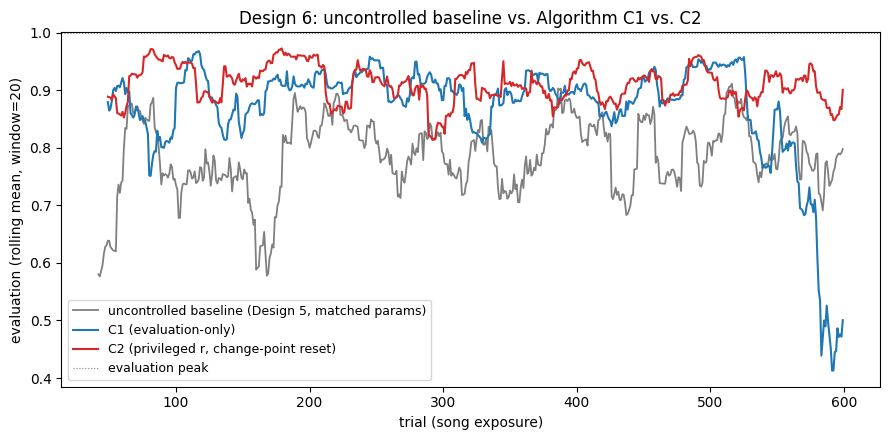

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df_baseline["trial"], df_baseline["evaluation_rolling_mean"], linewidth=1.3,
        color="tab:gray", label="uncontrolled baseline (Design 5, matched params)")
ax.plot(df_c1["trial"], df_c1["evaluation_rolling_mean"], linewidth=1.5,
        color="tab:blue", label="C1 (evaluation-only)")
ax.plot(df_c2["trial"], df_c2["evaluation_rolling_mean"], linewidth=1.5,
        color="tab:red", label="C2 (privileged r, change-point reset)")
ax.axhline(1.0, color="gray", linewidth=0.8, linestyle=":", label="evaluation peak")
ax.set_xlabel("trial (song exposure)")
ax.set_ylabel(f"evaluation (rolling mean, window={WINDOW})")
ax.set_title("Design 6: uncontrolled baseline vs. Algorithm C1 vs. C2")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("../results/figures/design6_evaluation_comparison.png", dpi=150)

## r trajectory (C2 only) -- where the change-point resets fire

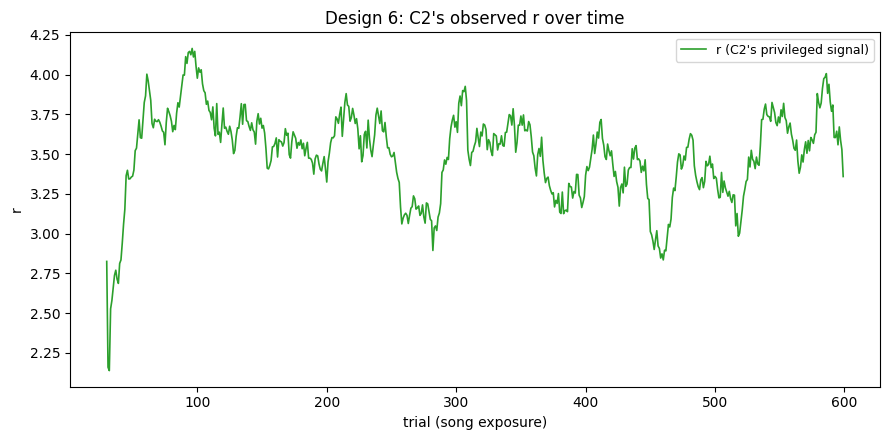

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df_c2["trial"], df_c2["r"], linewidth=1.2, color="tab:green",
        label="r (C2's privileged signal)")
ax.set_xlabel("trial (song exposure)")
ax.set_ylabel("r")
ax.set_title("Design 6: C2's observed r over time")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("../results/figures/design6_c2_r_trajectory.png", dpi=150)

## Convergence metrics

In [5]:
metrics_c1 = compute_convergence_metrics(df_c1, threshold=CONVERGENCE_THRESHOLD,
                                          sustain_window=SUSTAIN_WINDOW,
                                          steady_state_window=STEADY_STATE_WINDOW)
metrics_c2 = compute_convergence_metrics(df_c2, threshold=CONVERGENCE_THRESHOLD,
                                          sustain_window=SUSTAIN_WINDOW,
                                          steady_state_window=STEADY_STATE_WINDOW)

pd.DataFrame({"C1": metrics_c1, "C2": metrics_c2}).T

,convergence_trial,steady_state_mean
C1,None,None
C2,None,None


## Median / mean evaluation -- the more forgiving comparison

In [6]:
comparison = pd.DataFrame({
    "condition": ["uncontrolled baseline", "C1 (evaluation-only)", "C2 (privileged r)"],
    "median_evaluation": [df_baseline["evaluation"].median(), df_c1["evaluation"].median(),
                           df_c2["evaluation"].median()],
    "mean_evaluation": [df_baseline["evaluation"].mean(), df_c1["evaluation"].mean(),
                         df_c2["evaluation"].mean()],
}).set_index("condition")
comparison

,median_evaluation,mean_evaluation
condition,,
uncontrolled baseline,0.902377,0.785567
C1 (evaluation-only),0.949929,0.866896
C2 (privileged r),0.966298,0.910813


At these matched, deterministic settings, `evaluation`'s distribution is heavy-tailed on the
downside (unbounded below, only capped at 1 above -- see `inverted_parabola_left_anchored`), so
sustaining 20 straight trials at `evaluation >= 0.9` is a strict bar that none of the three
conditions reach here. Median/mean evaluation (above) is the more informative comparison at this
scale: C2 wins outright on both measures; C1 alone is a mixed bag against the uncontrolled
baseline -- a better median (fewer merely-mediocre trials) but a *worse* mean (evaluation-only
feedback alone doesn't reliably avoid occasional large negative excursions; only C2's r-aware
reset damps those out). Worth exploring further by lowering `CONVERGENCE_THRESHOLD`/`SUSTAIN_WINDOW`,
or tuning `BANDIT_C`/`R_CHANGE_THRESHOLD`.